In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error

### Single Linear Regression

In [3]:
# Random Data
x = np.array([5, 15, 25, 35, 45, 55]).reshape((-1, 1))
y = np.array([5, 20, 14, 32, 22, 38])

In [4]:
x # 2-D array

array([[ 5],
       [15],
       [25],
       [35],
       [45],
       [55]])

In [5]:
y # 1-D array

array([ 5, 20, 14, 32, 22, 38])

In [6]:
# create model and fit it
model = LinearRegression().fit(x, y)

In [7]:
# Check the results
r_sq = model.score(x, y)
print(f"Coefficient of determination: {r_sq*100}")

Coefficient of determination: 71.58756137479541


In [8]:
print(f"intercept: {model.intercept_}")
print(f"coefficient: {model.coef_}")

intercept: 5.633333333333329
coefficient: [0.54]


In [9]:
# Predict response
y_pred = model.predict(x)

print(f"predicted resposes: {y_pred}")

predicted resposes: [ 8.33333333 13.73333333 19.13333333 24.53333333 29.93333333 35.33333333]


In [10]:
x_new = np.arange(5).reshape((-1, 1))
x_new

array([[0],
       [1],
       [2],
       [3],
       [4]])

In [11]:
y_new = model.predict(x_new)
y_new

array([5.63333333, 6.17333333, 6.71333333, 7.25333333, 7.79333333])

### Multiple Linear Regression

In [12]:
x = [
    [0,1], [5,1], [15,2], [25,5], [35,11], [45,15], [55, 34], [60, 35]
]

y = [4, 5, 20, 14, 32, 22, 38, 43]

x,y = np.array(x),  np.array(y)

In [13]:
model = LinearRegression().fit(x, y)

In [14]:
r_sq = model.score(x, y)
print(f"Coefficient of determination: {r_sq*100}")

Coefficient of determination: 86.15939258756777


In [15]:
print(f"intercept: {model.intercept_}")
print(f"Coefficient: {model.coef_}")

intercept: 5.522579275198183
Coefficient: [0.44706965 0.25502548]


In [16]:
y_pred = model.predict(x)

print(f"predicted response: {y_pred}")

predicted response: [ 5.77760476  8.012953   12.73867497 17.9744479  23.97529728 29.4660957
 38.78227633 41.27265006]


### StatsModel

In [17]:
import statsmodels.api as sm

In [18]:
x = [
    [0,1], [5,1], [15,2], [25,5], [35,11], [45,15], [55, 34], [60, 35]
]

y = [4, 5, 20, 14, 32, 22, 38, 43]

x,y = np.array(x),  np.array(y)

In [19]:
x = sm.add_constant(x)

In [20]:
x

array([[ 1.,  0.,  1.],
       [ 1.,  5.,  1.],
       [ 1., 15.,  2.],
       [ 1., 25.,  5.],
       [ 1., 35., 11.],
       [ 1., 45., 15.],
       [ 1., 55., 34.],
       [ 1., 60., 35.]])

In [21]:
y

array([ 4,  5, 20, 14, 32, 22, 38, 43])

In [22]:
model = sm.OLS(y, x)

In [23]:
response = model.fit()

In [24]:
print(response.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.862
Model:                            OLS   Adj. R-squared:                  0.806
Method:                 Least Squares   F-statistic:                     15.56
Date:                Wed, 07 Jan 2026   Prob (F-statistic):            0.00713
Time:                        22:39:26   Log-Likelihood:                -24.316
No. Observations:                   8   AIC:                             54.63
Df Residuals:                       5   BIC:                             54.87
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          5.5226      4.431      1.246      0.2

/Users/neha/Documents/workspacee-ml/sampleMlProject/env/lib/python3.13/site-packages/scipy/stats/_axis_nan_policy.py:430: UserWarning: `kurtosistest` p-value may be inaccurate with fewer than 20 observations; only n=8 observations were given.
  return hypotest_fun_in(*args, **kwds)


### California Housing Data

In [25]:
from sklearn.datasets import fetch_california_housing

In [26]:
housing = fetch_california_housing()

In [27]:
df = pd.DataFrame(housing.data, columns=housing.feature_names)

In [28]:
df['HouseValue'] = housing.target

In [29]:
df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,HouseValue
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


#### Process the data

In [30]:
df.isnull().sum() # Check for missing values

MedInc        0
HouseAge      0
AveRooms      0
AveBedrms     0
Population    0
AveOccup      0
Latitude      0
Longitude     0
HouseValue    0
dtype: int64

In [31]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   MedInc      20640 non-null  float64
 1   HouseAge    20640 non-null  float64
 2   AveRooms    20640 non-null  float64
 3   AveBedrms   20640 non-null  float64
 4   Population  20640 non-null  float64
 5   AveOccup    20640 non-null  float64
 6   Latitude    20640 non-null  float64
 7   Longitude   20640 non-null  float64
 8   HouseValue  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


In [32]:
# All data is numeric so no conversion required

In [33]:
df.corr()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,HouseValue
MedInc,1.000000,-0.119034,0.326895,-0.062040,0.004834,0.018766,-0.079809,-0.015176,0.688075
HouseAge,-0.119034,1.000000,-0.153277,-0.077747,-0.296244,0.013191,0.011173,-0.108197,0.105623
AveRooms,0.326895,-0.153277,1.000000,0.847621,-0.072213,-0.004852,0.106389,-0.027540,0.151948
AveBedrms,-0.062040,-0.077747,0.847621,1.000000,-0.066197,-0.006181,0.069721,0.013344,-0.046701
Population,0.004834,-0.296244,-0.072213,-0.066197,1.000000,0.069863,-0.108785,0.099773,-0.024650
AveOccup,0.018766,0.013191,-0.004852,-0.006181,0.069863,1.000000,0.002366,0.002476,-0.023737
Latitude,-0.079809,0.011173,0.106389,0.069721,-0.108785,0.002366,1.000000,-0.924664,-0.144160
Longitude,-0.015176,-0.108197,-0.027540,0.013344,0.099773,0.002476,-0.924664,1.000000,-0.045967
HouseValue,0.688075,0.105623,0.151948,-0.046701,-0.024650,-0.023737,-0.144160,-0.045967,1.000000


In [34]:
correlation_matrix = df.corr()
print(correlation_matrix['HouseValue'])

MedInc        0.688075
HouseAge      0.105623
AveRooms      0.151948
AveBedrms    -0.046701
Population   -0.024650
AveOccup     -0.023737
Latitude     -0.144160
Longitude    -0.045967
HouseValue    1.000000
Name: HouseValue, dtype: float64


Text(0.5, 1.0, 'Correlation Matrix')

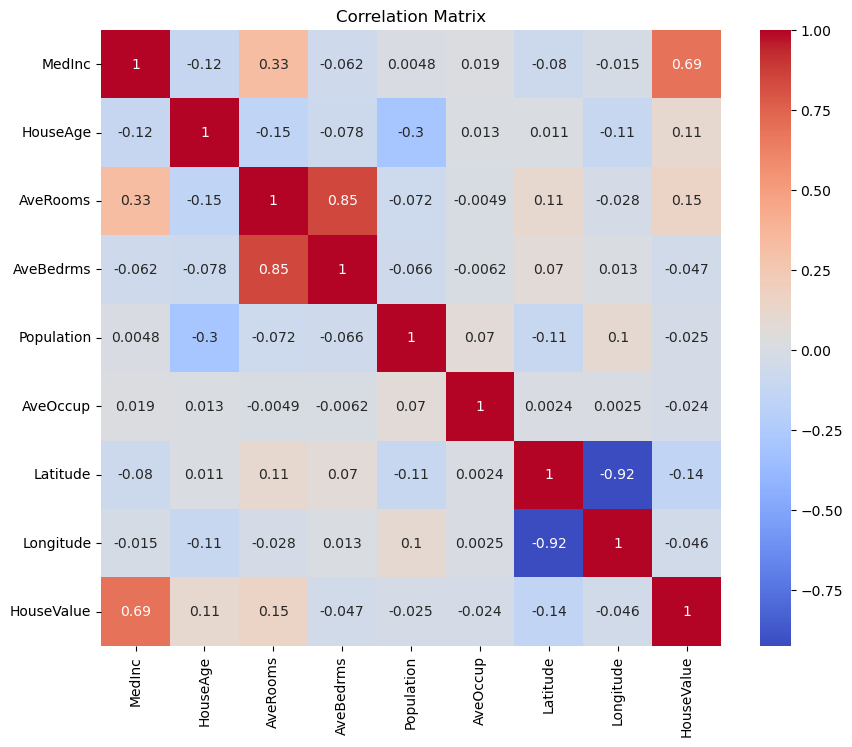

In [35]:
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")

In [36]:
#Will pick few important features, those are highly correlated with HouseValue
selected_features = ['MedInc', 'AveRooms', 'AveOccup']
X = df[selected_features]
y = df['HouseValue']

#### Feature Scaling
Standardization to ensure all features are on the same scale, improving model performance and comparability.
Standardization is a preprocessing technique that scales numerical features to have a mean of 0 and a standard deviation of 1. This process ensures that all features are on the same scale, which is essential for machine learning models sensitive to the input features’ scale. By standardizing the features, you can improve model performance and comparability by reducing the effect of features with large ranges dominating the model.

In [37]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)
X_scaled

array([[ 2.34476576,  0.62855945, -0.04959654],
       [ 2.33223796,  0.32704136, -0.09251223],
       [ 1.7826994 ,  1.15562047, -0.02584253],
       ...,
       [-1.14259331, -0.09031802, -0.0717345 ],
       [-1.05458292, -0.04021111, -0.09122515],
       [-0.78012947, -0.07044252, -0.04368215]], shape=(20640, 3))

In [38]:
model = LinearRegression()

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

In [39]:
print("Mean Squared Error:", mean_squared_error(y_test, y_pred))
print("R-squared:", r2_score(y_test, y_pred))

Mean Squared Error: 0.7006855912225249
R-squared: 0.4652924370503557


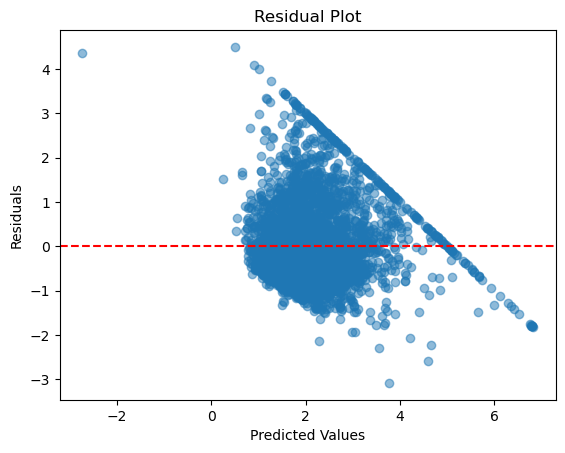

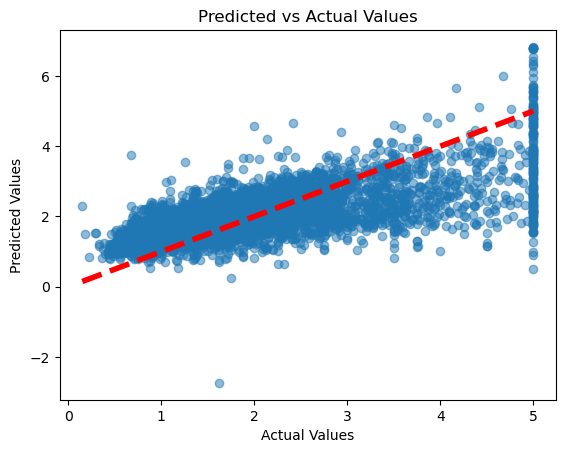

In [40]:
# Residual Plot
residuals = y_test - y_pred
plt.scatter(y_pred, residuals, alpha=0.5)
plt.xlabel('Predicted Values')
plt.ylabel('Residuals')
plt.title('Residual Plot')
plt.axhline(y=0, color='red', linestyle='--')
plt.show()

# Predicted vs Actual Plot
plt.scatter(y_test, y_pred, alpha=0.5)
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title('Predicted vs Actual Values')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=4)
plt.show()

In [41]:
X_train_sm = sm.add_constant(X_train)

model_sm = sm.OLS(y_train, X_train_sm).fit()

print(model_sm.summary())

                            OLS Regression Results                            
Dep. Variable:             HouseValue   R-squared:                       0.485
Model:                            OLS   Adj. R-squared:                  0.484
Method:                 Least Squares   F-statistic:                     5173.
Date:                Wed, 07 Jan 2026   Prob (F-statistic):               0.00
Time:                        22:45:35   Log-Likelihood:                -20354.
No. Observations:               16512   AIC:                         4.072e+04
Df Residuals:                   16508   BIC:                         4.075e+04
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          2.0679      0.006    320.074      0.0

Text(0.5, 1.0, 'Q-Q Plot of Residuals')

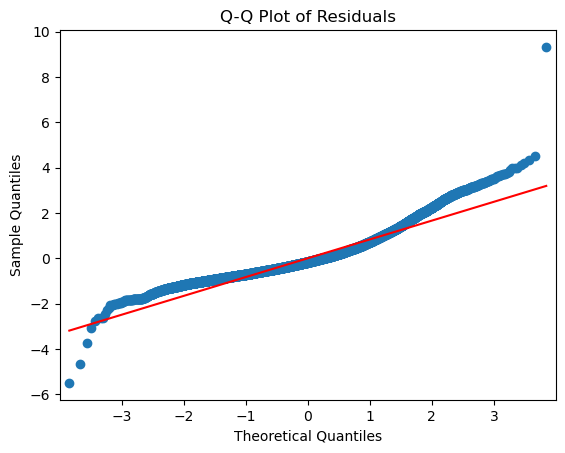

In [42]:
sm.qqplot(model_sm.resid, line='s')
plt.title('Q-Q Plot of Residuals')

In [43]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

vif_data = pd.DataFrame()
vif_data['Feature'] = selected_features
vif_data['VIF'] = [variance_inflation_factor(X_scaled, i) for i in range(X_scaled.shape[1])]
print(vif_data)

    Feature       VIF
0    MedInc  1.120166
1  AveRooms  1.119797
2  AveOccup  1.000488


Text(0, 0.5, 'VIF Value')

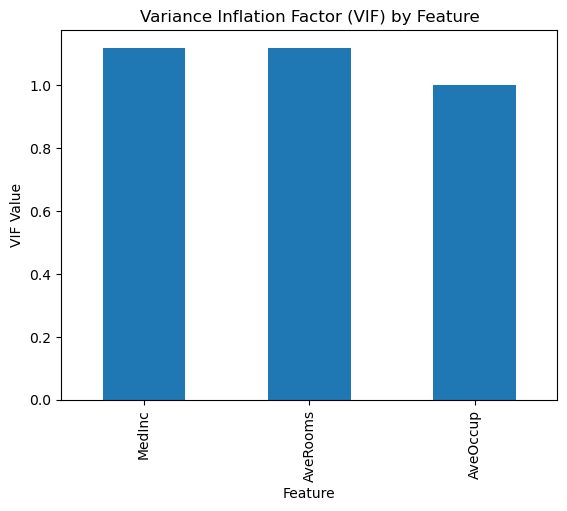

In [44]:
vif_data.plot(kind='bar', x='Feature', y='VIF', legend=False)
plt.title('Variance Inflation Factor (VIF) by Feature')
plt.ylabel('VIF Value')

### Boston Housing